# AnalystLab Africa Data Analytics Internship Program

## Week 2: Data Cleaning & Exploratory Data Analysis (EDA)

### Dataset: Netflix Movies & TV Shows

**Prepared by:** DANJUMA ZAINAB

---

## Objective

The objective of this project is to clean, validate, and explore the Netflix Movies & TV Shows dataset in order to transform raw data into a structured and analysis-ready dataset while identifying meaningful insights through Exploratory Data Analysis (EDA).

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# 2. Load Dataset

In [2]:
df = pd.read_csv("C:/Users/zainab/Desktop/Week 2 Netflix EDA/Data/netflix_titles.csv")

In [3]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


# 3. Dataset Understanding

### 3.1 Display number of columns and rows 

In [4]:
df.shape

(8807, 12)

## interpretation

The Netflix dataset contains **8,807 rows** and **12 columns**

## 3.2. Display Column Names

The column names are displayed to understand the variables available in the dataset before beginning the data cleaning process. 

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## Interpretation

The dataset consist of 12 columns these columns are show_id, type, title, director, cast, country, date_added,
       release_year, rating, duration, listed_in, description.

## 3.3. Display Data types

In [6]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

## 3.4. Display Column info

This tells us:
- Number of rows
- Number of columns
- Missing values
- Data types


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 3.5. Display all Numerical Columns

In [8]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)

Index(['release_year'], dtype='object')


## 3.6. Display all Categorical Column

In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


## 3.7 Check for Possible Primary Keys



#### Check the number of unique values in each column

In [9]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

## 3.8. Check if any Column is completely Unique

In [10]:
for col in df.columns:
    if df[col].is_unique:
        print(f"{col} is unique and could be a primary key.")
    else:
        print(f"{col} is NOT unique.")

show_id is unique and could be a primary key.
type is NOT unique.
title is unique and could be a primary key.
director is NOT unique.
cast is NOT unique.
country is NOT unique.
date_added is NOT unique.
release_year is NOT unique.
rating is NOT unique.
duration is NOT unique.
listed_in is NOT unique.
description is NOT unique.


### Possible Primary Key

The dataset was examined to identify possible unique identifiers. Both the **show_id** and **title** columns contain unique values in this dataset. However, **show_id** was selected as the primary key because it is a system-generated identifier that uniquely identifies each Netflix title. The **title** column is descriptive and may not remain unique in other versions of the dataset.

## 3.9. Dataset Understanding

The Netflix Movies & TV Shows dataset contains information about movies and television shows available on Netflix. The dataset includes details such as title, type, director, cast, country, release year, rating, duration, date added, and genre.

The dataset was successfully loaded into Python using Pandas. The structure, dimensions, data types, numerical and categorical features were examined. 

# 4. Data Cleaning

## 4.1. Check for Missing Value

The dataset was examined for missing values to identify incomplete records that could affect the quality of the analysis. A summary table was generated to show the total number and percentage of missing values in each column.



### Missing Values

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table

,Missing Values,Percentage (%)
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
release_year,0,0.00
rating,4,0.05
duration,3,0.03


## Missing Value(Report)

The results indicate that the **director** column has the highest number of missing values (2,634 records; 29.91%), followed by **country** (831 records; 9.44%) and **cast** (825 records; 9.37%). The **date_added**, **rating**, and **duration** columns contain only a few missing values, while the remaining columns have no missing values.

Appropriate data cleaning techniques will be applied based on the nature and importance of each column to ensure the dataset is suitable for analysis.

## 4.2. Handling Missing Values 



### 4.2.1. Fill the text columns

In [13]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

### 4.2.2. Remove rows with missing values in the remaining columns

In [14]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])

### 4.2.3.Confirm all missing values have been handled

In [15]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table

,Missing Values,Percentage (%)
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
cast,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0


## Handling Missing Values (Report)

Missing values in the **director**, **cast**, and **country** columns were replaced with **"Unknown"** because these are categorical fields and the missing information could not be reliably inferred.

Rows containing missing values in the **date_added**, **rating**, and **duration** columns were removed because they represented a very small proportion of the dataset and were important for time-based analysis and content classification.

After applying these cleaning steps, the dataset contained no remaining missing values.

## 4.3. Duplicate Records

Duplicate records were checked to identify repeated entries that could affect the accuracy of the analysis. Duplicate rows can lead to biased results by counting the same observation multiple times. Therefore, identifying and removing duplicate records is an important step in the data cleaning process.

In [16]:
df.duplicated().sum()

np.int64(0)

###  Duplicate Records (Report)

The dataset was examined for duplicate records using the `duplicated()` function. The analysis showed that there were no duplicate records in the dataset. Therefore, no rows were removed, and the dataset was considered free of duplicate observations.

## 4.4. Standardization

## 4.4.1. Standardize column names

To improve consistency and readability, all column names were standardized by removing extra spaces, converting all characters to lowercase, and replacing spaces with underscores. This naming convention makes the dataset easier to work with in Python and reduces the likelihood of coding errors.

In [17]:

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

### 4.4.2. Standardize Date Format

In [18]:
df['date_added'].dtype

dtype('O')

In [19]:
df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),
    errors='coerce'
)

In [20]:
df['date_added'].dtype

dtype('<M8[ns]')

In [21]:
df['date_added'].isnull().sum()

np.int64(0)

### Date Standardization (Report)

The **date_added** column was originally stored as a text (object) data type. It was converted to the datetime format using the `pd.to_datetime()` function after removing leading and trailing spaces with the `str.strip()` method.

The conversion was successful, and no invalid or missing dates were introduced during the process. The column is now stored as the `datetime64[ns]` data type, making it suitable for time-based analysis.

### 4.4.3. Verify Data types

In [22]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

### Data Type Verification (Report)

The data types of all variables were verified after the data cleaning process. The **date_added** column was successfully converted to the `datetime64[ns]` data type, while the **release_year** column remained as an integer. All remaining columns were stored as object (text) data types, which are appropriate for categorical and descriptive information.

The dataset is now correctly structured and ready for further analysis.

# 4.5.Data Validation

## 4.5.1. Check Content Type

In [23]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

## 4.5.2 Check Missing or Invalid Ratings

In [24]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

## 4.5.3 Check Duration

In [25]:
df['duration'].value_counts().head(10)

duration
1 Season     1791
2 Seasons     421
3 Seasons     198
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

## Interpretation

### Duration Validation

The **duration** column was examined to verify that movie durations (measured in minutes) and TV show durations (measured in seasons) were consistently recorded.

The results indicate that **1 Season** is the most common duration among TV Shows, while movie durations are mostly concentrated between **90 and 97 minutes**. No invalid or inconsistent duration formats were identified after the data cleaning process.

## 4.5.4 Check Release Year

In [26]:
df['release_year'].describe()


count    8790.000000
mean     2014.183163
std         8.825466
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [27]:
df.to_csv("Netflix_Cleaned.csv", index=False)

In [28]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Interpretation

### Release Year Validation

The **release_year** column was examined to verify that all recorded years were within a reasonable range.

The dataset contains titles released between **1925 and 2021**, with an average release year of approximately **2014**. The distribution indicates that most Netflix titles were released in recent years, and no unrealistic or invalid release years were identified.

# 4.6 Cleaning Summary

| Issue Identified | Action Taken |
|------------------|--------------|
| Missing Values | Missing values in **director**, **cast**, and **country** were replaced with **"Unknown"**. Rows with missing values in **date_added**, **rating**, and **duration** were removed. |
| Duplicate Records | No duplicate records were found; therefore, no rows were removed. |
| Column Names | Standardized by converting all names to lowercase and replacing spaces with underscores. |
| Date Format | Converted the **date_added** column from object to datetime format. |
| Data Types | Verified and confirmed that all columns have appropriate data types. |
| Data Validation | Checked content type, duration, ratings, and release years. No major inconsistencies or invalid records were identified after cleaning. |

# 5. Exploratory Data Analysis (EDA)

## 5.1 Summary Statistics

Summary statistics were generated to understand the distribution and characteristics of the numerical variables in the cleaned Netflix dataset. The analysis provides an overview of the central tendency and spread of the numerical data, helping to identify potential patterns before further exploration.

In [29]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [30]:
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225408,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466



### Interpretation

Summary statistics were generated to examine the numerical characteristics of the cleaned Netflix dataset. The dataset contains **8,790** records with valid values for both the **date_added** and **release_year** columns.

The **release_year** ranges from **1925** to **2021**, with an average release year of approximately **2014**. The median release year is **2017**, indicating that more than half of the titles were released in or after 2017. The relatively small standard deviation (8.83 years) suggests that a large proportion of Netflix content consists of relatively recent releases.

The **date_added** column shows that Netflix added content to its platform between **2008** and **2021**, reflecting the continuous expansion of its content library over time.

## 5.2 Movies vs TV Shows Distribution

This analysis examines the distribution of Movies and TV Shows available on Netflix to determine which type of content dominates the platform's library.

In [31]:
content_type = df['type'].value_counts()
content_type

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

### Interpretation

The Netflix content library is dominated by **Movies**, which account for **6,126** titles (approximately 70% of the dataset), while **TV Shows** account for **2,664** titles (approximately 30%). This indicates that Netflix offers a significantly larger collection of movies than television series.

## 5.3 Content Added by Year

This analysis examines the number of titles added to Netflix each year to identify growth patterns in the platform's content library.

In [32]:
content_by_year = (
    df['date_added']
      .dt.year
      .value_counts()
      .sort_index()
)

content_by_year

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

### Interpretation

The analysis shows that Netflix expanded its content library rapidly between **2016 and 2020**. The highest number of titles was added in **2019** (2,016 titles), followed by **2020** (1,879 titles). A slight decline in new additions is observed in **2021**, which may reflect changes in content acquisition or production during that period.

## 5.4 Top Content-Producing Countries

This analysis identifies the countries that contributed the highest number of Movies and TV Shows available on Netflix.


In [33]:
top_countries = (
    df[df['country'] != 'Unknown']['country']
      .str.split(', ')
      .explode()
      .value_counts()
      .head(10)
)

top_countries

country
United States     3680
India             1046
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

### Interpretation

The analysis shows that the **United States** is the largest contributor to Netflix's content library with **3,680** titles, followed by **India** with **1,046** titles and the **United Kingdom** with **803** titles. The **Unknown** category represents records where the country information was unavailable during data collection. These findings indicate that Netflix's content is heavily concentrated in a few major production markets while also maintaining a diverse international catalog.

## 5.5 Most Common Ratings

This analysis identifies the audience ratings that appear most frequently across Netflix content.

In [34]:
ratings = df['rating'].value_counts()

ratings

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

### Interpretation

The most common audience rating is **TV-MA**, with **3,205** titles, followed by **TV-14** with **2,157** titles. This suggests that a large proportion of Netflix's content is intended for mature and teenage audiences, while content for younger children represents a smaller share of the library.

## 5.6 Most Common Genres

This analysis identifies the genres that appear most frequently within the Netflix content library.

In [35]:
genres = (
    df['listed_in']
      .str.split(', ')
      .explode()
      .value_counts()
      .head(10)
)

genres

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

### Interpretation

The most common genre on Netflix is **International Movies** with **2,752** titles, followed by **Dramas** (2,426) and **Comedies** (1,674). This indicates that Netflix offers a diverse global content library with a strong emphasis on international productions and drama-related entertainment.

## 5.7 Key Findings

- Movies account for the majority of Netflix's content library, representing approximately 70% of all titles.
- Netflix experienced rapid growth in content additions between 2017 and 2020, with the highest number of titles added in 2019.
- The United States is the leading content-producing country, followed by India and the United Kingdom.
- TV-MA is the most common audience rating, indicating that much of Netflix's content targets mature audiences.
- International Movies and Dramas are the most common genres available on the platform.

## 5.8 Business Recommendations

- Continue investing in international productions to maintain a diverse global content library.
- Increase content acquisition from underrepresented regions to improve geographical diversity.
- Expand family-friendly programming to balance the large proportion of mature-rated content.
- Maintain strategic investments in high-performing markets such as the United States, India, and the United Kingdom while exploring emerging markets.
- Continue monitoring audience preferences to optimize future content acquisition and production strategies.

# 6. Visualization

## 6.1 Distribution of  Movies vs TV Shows

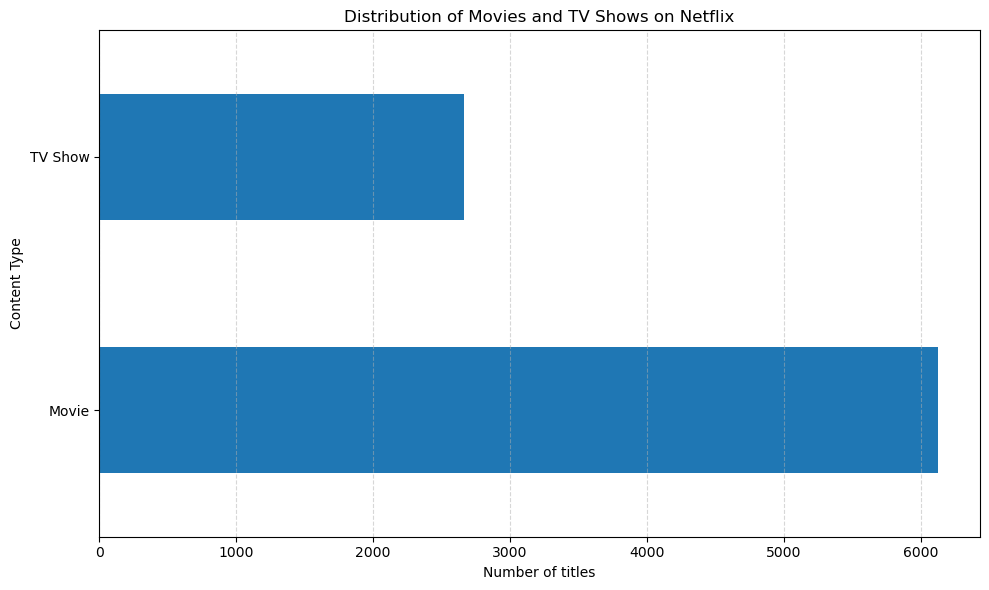

In [36]:


plt.figure(figsize=(10,6))

content_type.plot(kind='barh')

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Number of titles")
plt.ylabel("Content Type")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows that Movies make up the largest proportion of Netflix's content library, with 6,126 titles compared to 2,664 TV Shows. This indicates that Netflix places a stronger emphasis on offering movies, providing viewers with a wider selection of films than television series.

## 6.2 Netflix Content Added by year

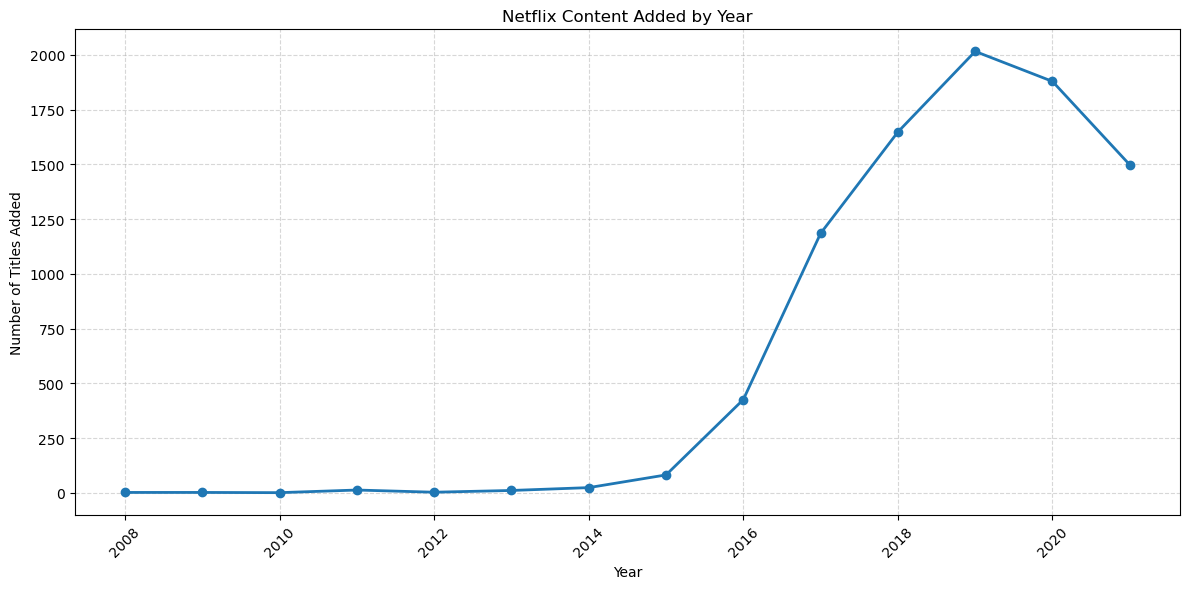

In [37]:
plt.figure(figsize=(12,6))

content_by_year.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.xticks(rotation=45)

plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The line chart illustrates a steady increase in the number of titles added to Netflix over the years, with content additions peaking in 2019. Although there was a slight decline in 2020 and 2021, Netflix continued to expand its content library significantly during this period.

## 6.3 Top 10 Content-Producing Countries

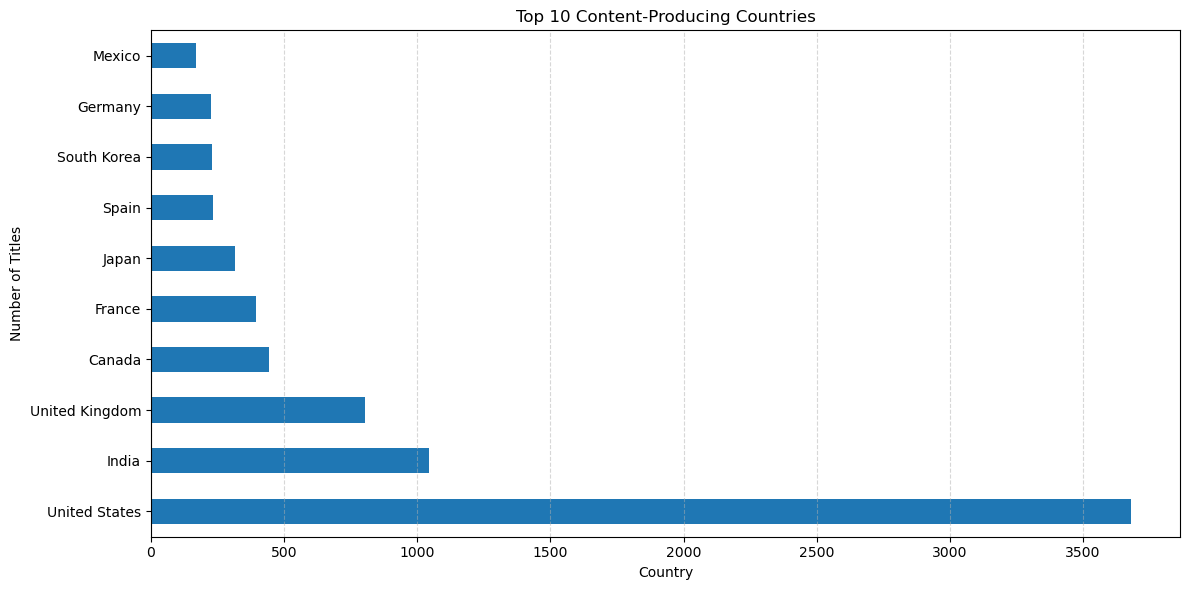

In [38]:


plt.figure(figsize=(12,6))

top_countries.plot(kind='barh')

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart indicates that the United States is the largest contributor to Netflix's content library, followed by India and the United Kingdom. This demonstrates that Netflix sources a substantial proportion of its content from a few major production markets while maintaining a diverse international catalog.

## 6.4 Distribution of Netflix Content Ratings

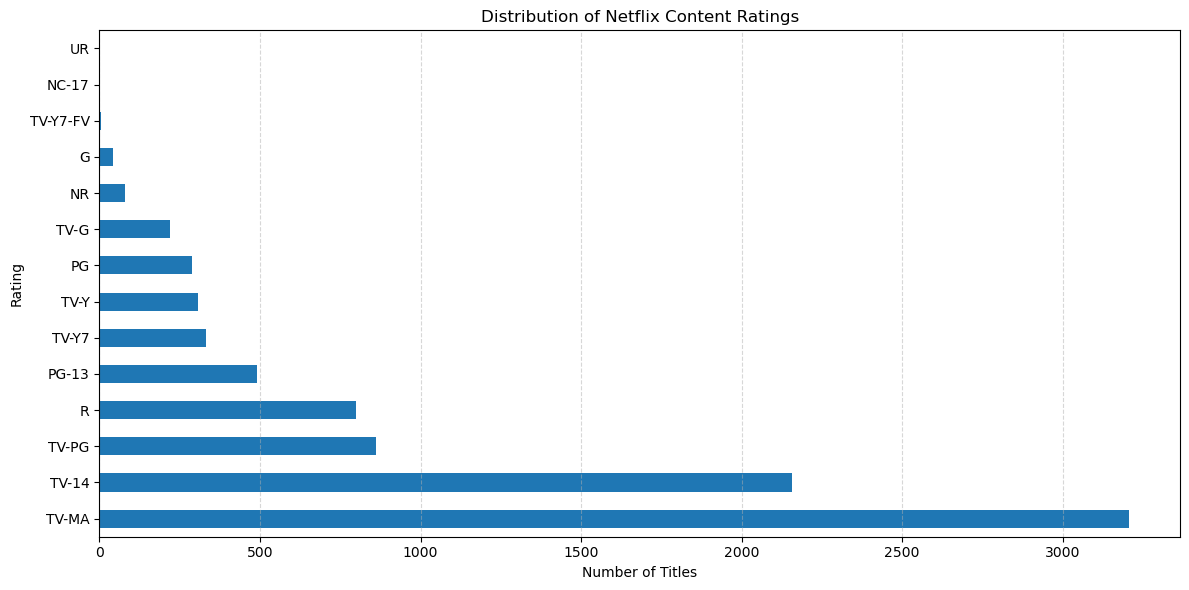

In [39]:




plt.figure(figsize=(12,6))

ratings.plot(kind='barh')

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The chart shows that TV-MA is the most common content rating, followed by TV-14. This suggests that a large share of Netflix's catalog is designed for mature and teenage audiences, while content intended for younger viewers represents a smaller proportion of the platform.

## 6.5 Top 10 Genres

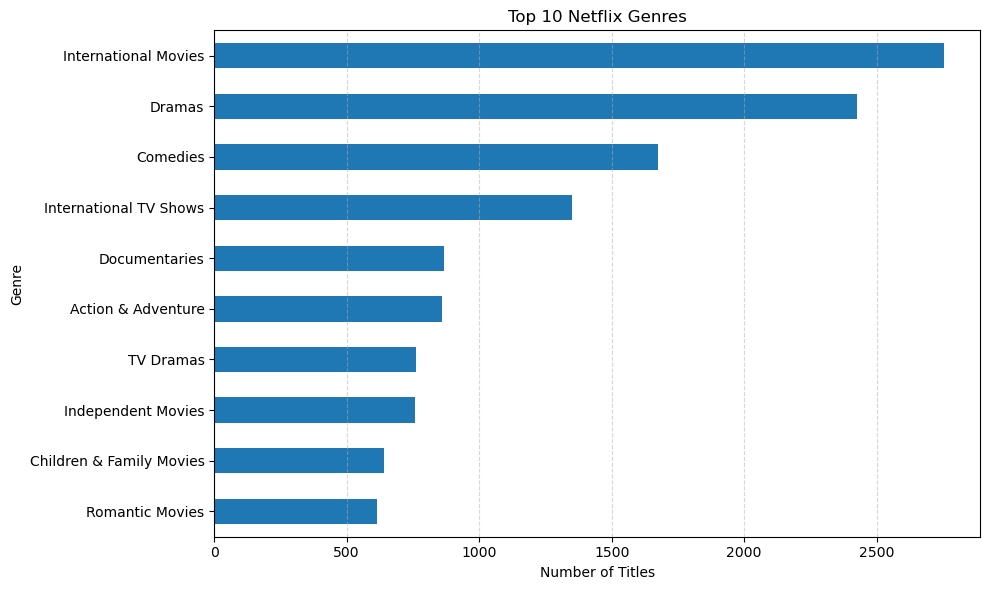

In [40]:
plt.figure(figsize=(10,6))
genres.sort_values().plot(kind='barh')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The horizontal bar chart reveals that International Movies, Dramas, and Comedies are the most common genres available on Netflix. This reflects Netflix's strong investment in globally diverse content while maintaining a broad selection of popular entertainment genres.